In [5]:
# ===============================================
# EXPERIMENT 3 - TITANIC DATASET
# Logistic Regression, LDA and KNN
# ===============================================

import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load Titanic Dataset
df = sns.load_dataset("titanic")

print(df.head())
print(df.info())

# Select useful columns
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']]

# Handle Missing Values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Encode Categorical Columns
df['sex'] = df['sex'].map({'male':0,'female':1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

# Features and Target
X = df.drop('survived', axis=1)
y = df['survived']

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train,y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test,lr_pred)

print("Logistic Regression Accuracy:",lr_accuracy*100)

# ==========================================
# Linear Discriminant Analysis
# ==========================================

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train,y_train)

lda_pred = lda_model.predict(X_test)

lda_accuracy = accuracy_score(y_test,lda_pred)

print("LDA Accuracy:",lda_accuracy*100)

# ==========================================
# KNN
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train,y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test,knn_pred)

print("KNN Accuracy:",knn_accuracy*100)

# ==========================================
# Comparison
# ==========================================

comparison = pd.DataFrame({
    "Classifier":[
        "Logistic Regression",
        "Linear Discriminant Analysis",
        "KNN"
    ],
    "Accuracy":[
        lr_accuracy*100,
        lda_accuracy*100,
        knn_accuracy*100
    ]
})

print(comparison)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

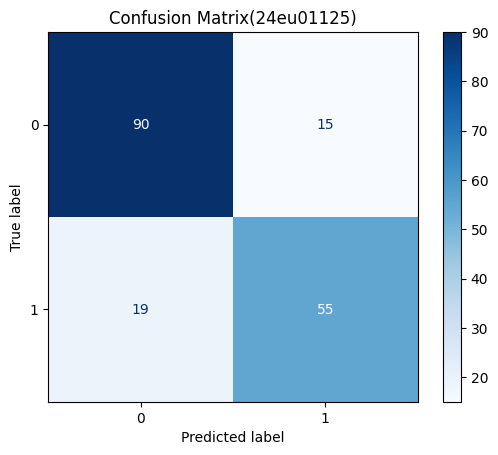

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix(24eu01125)")
plt.show()

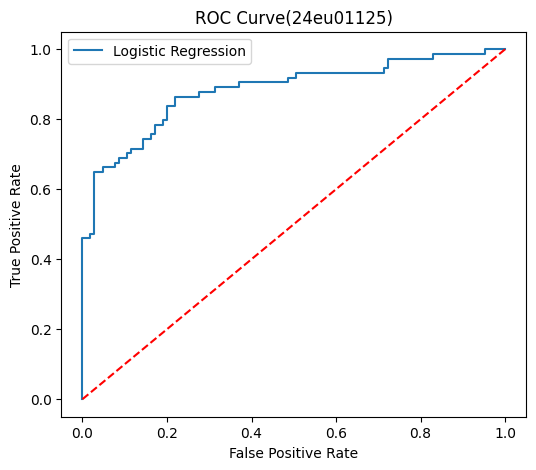

AUC Score: 0.881981981981982


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve(24eu01125)")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test,y_prob))

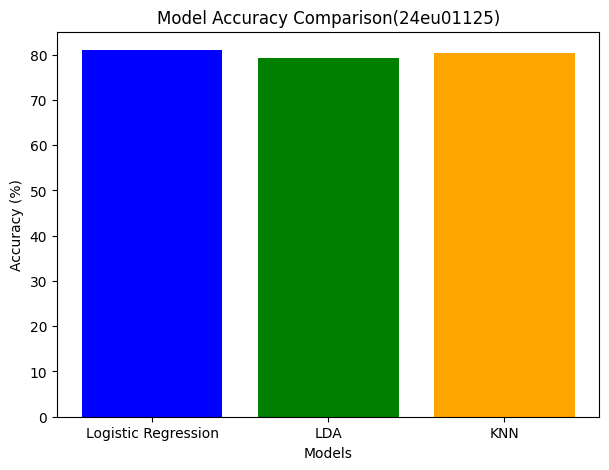

In [9]:
import matplotlib.pyplot as plt

models = ['Logistic Regression','LDA','KNN']
accuracy = [lr_accuracy*100, lda_accuracy*100, knn_accuracy*100]

plt.figure(figsize=(7,5))
plt.bar(models, accuracy, color=['blue','green','orange'])
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison(24eu01125)")
plt.show()